<a href="https://colab.research.google.com/github/Navya28-khanna/ML_LAB/blob/main/Lab_10_ANN_and_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [3]:
#load dataset
df = pd.read_excel("german credit.xlsx")

# clean column names
df.columns = df.columns.str.strip()

# rename target
df.rename(columns={"Column1": "Target"}, inplace=True)

df.head()

,Status of existing checking account,Duration,Credit history,Purpose,Target,Savings account/bonds,Present employment since,Installment rate in percentage of disposable income,Personal status and sex,Other debtors / guarantors,...,Property,Age,Other installment plans,Housing,Number of existing credits at this bank,Job,Number of people being liable to provide maintenance for,Telephone,foreign worker,No. Of children
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


In [4]:
#basic EDA
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                                                    Non-Null Count  Dtype 
---  ------                                                    --------------  ----- 
 0   Status of existing checking account                       1000 non-null   object
 1   Duration                                                  1000 non-null   int64 
 2   Credit history                                            1000 non-null   object
 3   Purpose                                                   1000 non-null   object
 4   Target                                                    1000 non-null   int64 
 5   Savings account/bonds                                     1000 non-null   object
 6   Present employment since                                  1000 non-null   object
 7   Installment rate in percentage of disposable income       1000 non-null   int64 
 8   Personal status and sex      

,0
Status of existing checking account,0
Duration,0
Credit history,0
Purpose,0
Target,0
Savings account/bonds,0
Present employment since,0
Installment rate in percentage of disposable income,0
Personal status and sex,0
Other debtors / guarantors,0


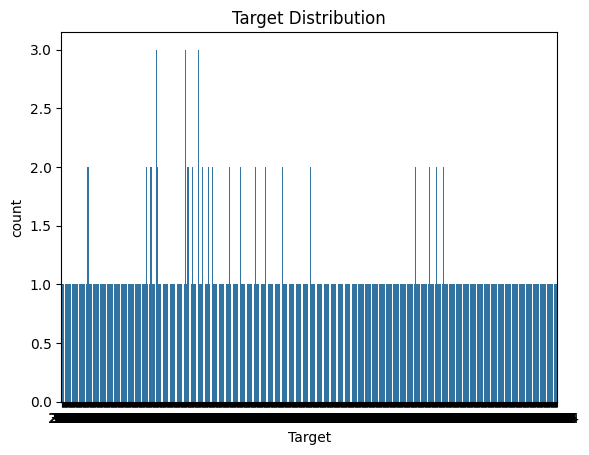

In [5]:
#target distribution
sns.countplot(x="Target", data=df)
plt.title("Target Distribution")
plt.show()

In [6]:
df.fillna(df.mode().iloc[0], inplace=True)

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [8]:
#split feature
X = df.drop("Target", axis=1)
y = df["Target"]

In [9]:
#train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
#train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [11]:
#prediction and evaluation
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.0
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
              precision    recall  f1-score   support

         276       0.00      0.00      0.00       1.0
         368       0.00      0.00      0.00       1.0
         385       0.00      0.00      0.00       1.0
         428       0.00      0.00      0.00       0.0
         433       0.00      0.00      0.00       1.0
         448       0.00      0.00      0.00       0.0
         458       0.00      0.00      0.00       1.0
         484       0.00      0.00      0.00       1.0
         518       0.00      0.00      0.00       1.0
         522       0.00      0.00      0.00       0.0
         585       0.00      0.00      0.00       1.0
         601       0.00      0.00      0.00       1.0
         609       0.00      0.00      0.00       1.0
         626       0.00      0.00      0.00       1.0
         660       0.00      0.00      0.00       1.0
 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

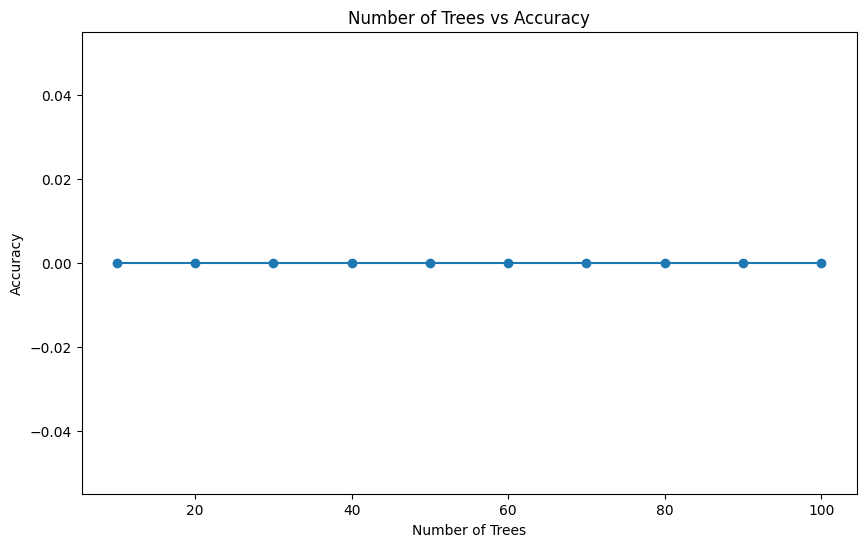

In [12]:
ntree = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
accuracy = []

for n in ntree:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)

    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy.append(acc)

plt.figure(figsize=(10,6))
plt.plot(ntree, accuracy, marker='o')
plt.title("Number of Trees vs Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.show()

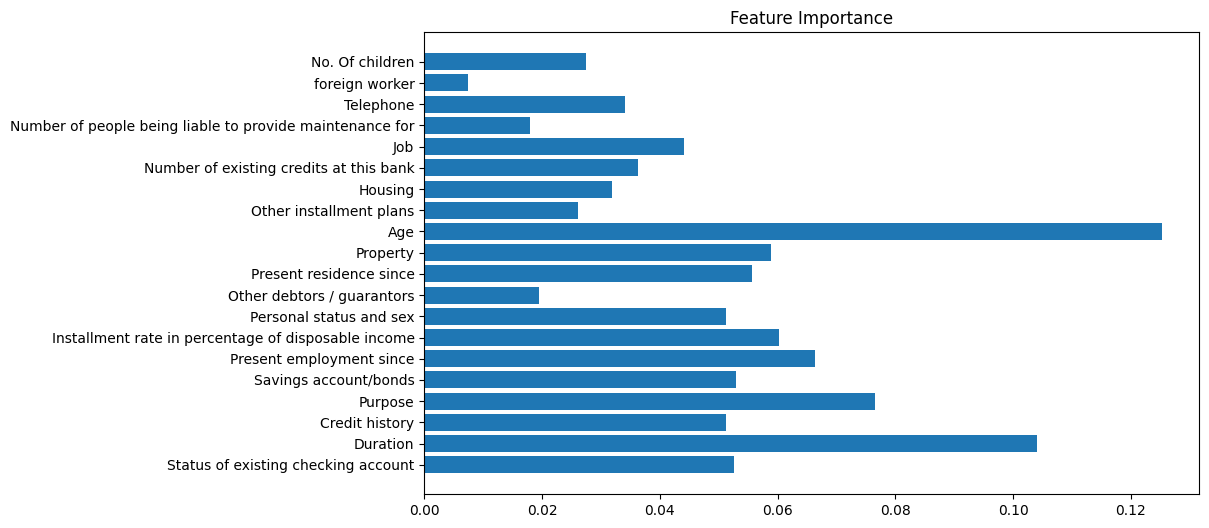

In [13]:
#feature importance
importances = rf.feature_importances_

plt.figure(figsize=(10,6))
plt.barh(X.columns, importances)
plt.title("Feature Importance")
plt.show()

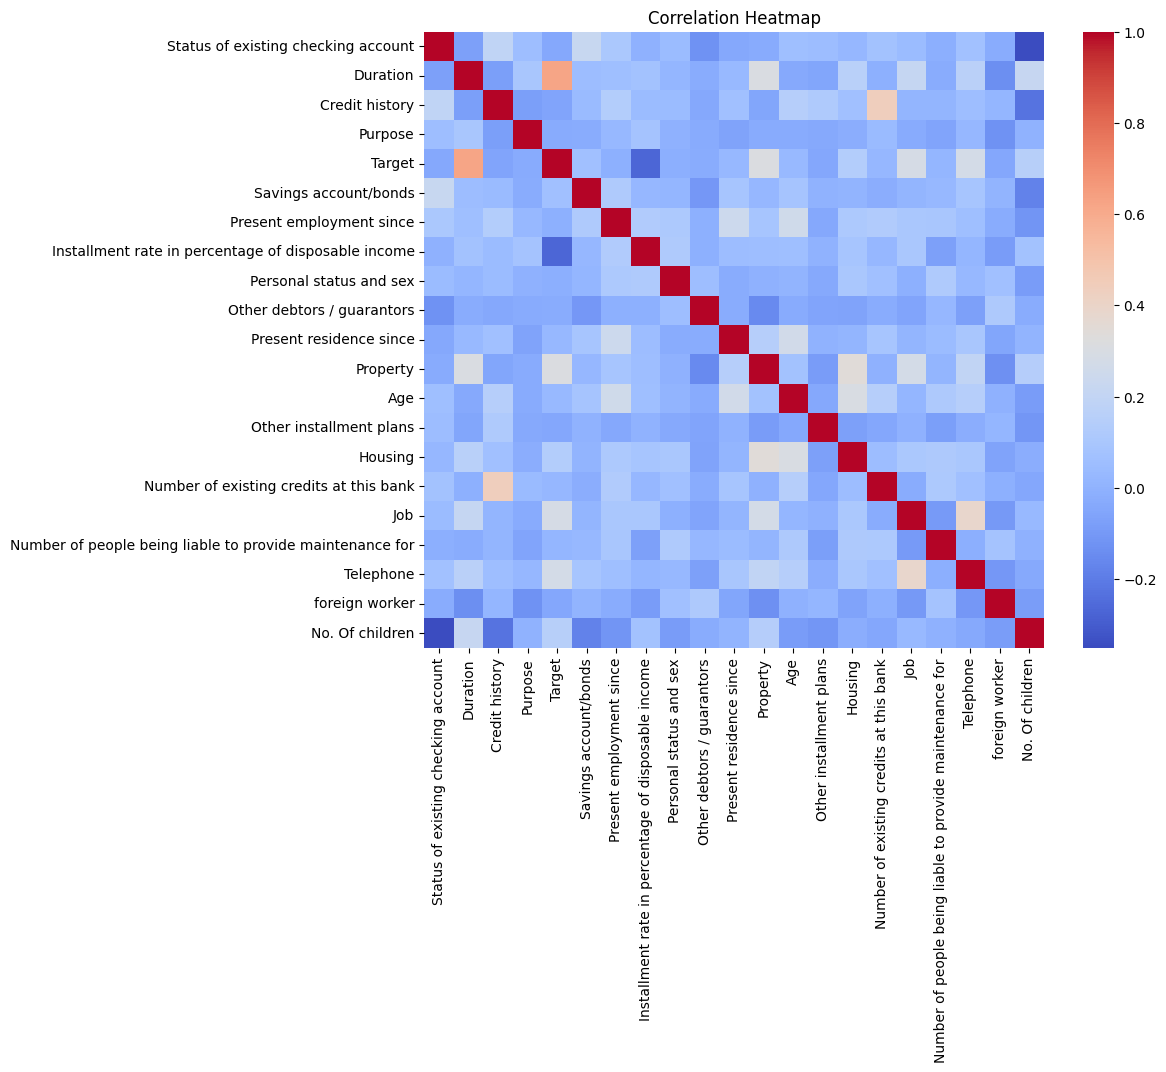

In [14]:
#heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [15]:
#hyperparameter tuning
params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

print("Best Params:", grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


Best Params: {'max_depth': None, 'n_estimators': 50}


In [17]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [21]:
#build ann model
model = Sequential()

model.add(Dense(64, activation='relu', input_dim=X_train.shape[1]))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))  # binary classification

In [22]:
#compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
#train model
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.0000e+00 - loss: -65879.9531 - val_accuracy: 0.0000e+00 - val_loss: -107311.1484
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -176520.5000 - val_accuracy: 0.0000e+00 - val_loss: -235238.5469
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: -352470.1562 - val_accuracy: 0.0000e+00 - val_loss: -446649.4062
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -655472.1250 - val_accuracy: 0.0000e+00 - val_loss: -808306.5000
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0000e+00 - loss: -1156791.2500 - val_accuracy: 0.0000e+00 - val_loss: -1388623.3750
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: -1933168.0000 - val_accuracy: 0.0000e+00 - val_loss: -2258166.2500
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: -3049905.5000 - val_accuracy: 0.0000e

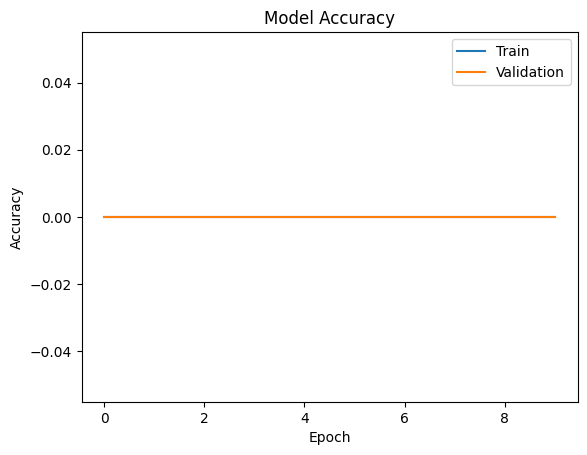

In [24]:
#accuracy graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])

plt.show()

In [25]:
#evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0000e+00 - loss: -9459723.0000  
Test Accuracy: 0.0
